# IoMT Ağlarında Hibrit Saldırı Tespit Sistemi
### CICIoMT2024 Üzerinde Denetimli (XGBoost) + Denetimsiz (Otoenkoder) ML

| | |
|---|---|
| **Üniversite** | Sakarya Üniversitesi |
| **Ders** | Siber Güvenlik Analitiği |
| **Yazarlar** | AMRO MOUSA ISMAIL BASEET (Y255012028) · MOTAZ ARMASH (Y255012163) |
| **Tarih** | 5 Mayıs 2026 |

---
**Bu notebook'un amacı:** Ders projesi süresince **adım-adım ne yaptığımızı** ve **ne bulduğumuzu** göstermek. Yaklaşık **15 dakikalık canlı sunum**.

## 📋 Yaptıklarımızın Özeti

| # | Adım | Amaç |
|---|---|---|
| 1 | **Veri Setini Tanıma** | CICIoMT2024 — 5.4M akış, 19 sınıf, 44 özellik |
| 2 | **EDA** | Sınıf dengesizliği (2,374:1) ve ayırıcı özelliklerin tespiti |
| 3 | **Önişleme** | Drate (sabit) düşür, StandardScaler, train/val/test split |
| 4 | **Faz 4: Denetimli (8 Konfigürasyon)** | RF/XGB × reduced/full × Original/SMOTE — E1–E8 |
| 5 | **Final Model: E7 (XGBoost full Original)** | %99.27 accuracy, 0.9076 macro F1, 0.9906 MCC |
| 6 | **Faz 5: Denetimsiz (Otoenkoder)** | Yalnızca benign ile eğit → anomali tespit |
| 7 | **AE vs Isolation Forest Karşılaştırması** | AUC 0.9892 vs 0.8612 — **+12.8 pp fark** |
| 8 | **Hibrit Demo** | 10 örnek üzerinde XGBoost + AE birlikte canlı çıkarım |

## 🎯 Üç Ana Bulgumuz

1. **AE > IF: +12.8 pp AUC** — hibrit yaklaşımın ampirik gerekçesi
2. **SMOTETomek 4/4 konfigde zarar verdi** — counterintuitive bulgu (textbook der "kullan")
3. **n=2,941 eşiği** — F1 < 0.85 olan tüm sınıfların support'u bu eşiğin altında; sınırlama dataset, model değil

> **Bilimsel Dürüstlük Notu:** Tüm sayılar `results/` ve `eda_output/` altındaki kanonik dosyalardan yüklenir. Reproducibility için: `scripts/run_e5g_gini_baseline.py` ve `scripts/verify_report_numbers.py`.

## ⚙️ Setup

*Kütüphaneler, yollar, seed değerleri.*

In [1]:
# Standard library
import os
import sys
import json
import random
import warnings
warnings.filterwarnings('ignore')

# Data
import numpy as np
import pandas as pd

# Visualization
import matplotlib.pyplot as plt
import seaborn as sns
from matplotlib.patches import Patch

# ML utilities
import joblib
from sklearn.metrics import (
    accuracy_score, f1_score, matthews_corrcoef,
    classification_report, confusion_matrix, roc_auc_score, roc_curve,
)

# Reproducibility (TensorFlow seed deferred to Phase 5 cell)
SEED = 42
np.random.seed(SEED)
random.seed(SEED)

# Matplotlib defaults — single style applied globally
plt.rcParams.update({
    'figure.dpi': 100,
    'savefig.dpi': 150,
    'font.size': 11,
    'axes.titlesize': 13,
    'axes.labelsize': 11,
    'legend.fontsize': 10,
})
sns.set_style('whitegrid')

print(f"Kutuphaneler yuklendi (random seed = {SEED})")

Kutuphaneler yuklendi (random seed = 42)


In [2]:
# Project paths — relative to home directory (no hard-coded absolute paths)
PROJECT_ROOT = os.path.expanduser('~/IoMT-Project')
PREPROCESSED = os.path.join(PROJECT_ROOT, 'preprocessed')
RESULTS      = os.path.join(PROJECT_ROOT, 'results')
EDA_OUTPUT   = os.path.join(PROJECT_ROOT, 'eda_output')

# Verify the project root is reachable
if not os.path.isdir(PROJECT_ROOT):
    raise FileNotFoundError(
        f"Proje koku bulunamadi: {PROJECT_ROOT}\n"
        f"Bu notebook ~/IoMT-Project altinda calisacak sekilde tasarlanmistir."
    )

# Version reporting via importlib (avoids eager imports of heavy packages)
from importlib.metadata import version, PackageNotFoundError

def _pkg_version(pkg_name):
    """Return installed version of pkg_name, or 'n/a' if not installed."""
    try:
        return version(pkg_name)
    except PackageNotFoundError:
        return 'n/a'

print(f"Proje koku       : {PROJECT_ROOT}")
print(f"  preprocessed/  : {os.path.isdir(PREPROCESSED)}")
print(f"  results/       : {os.path.isdir(RESULTS)}")
print(f"  eda_output/    : {os.path.isdir(EDA_OUTPUT)}")
print()
print(f"Paket surumleri:")
for pkg in ['numpy', 'pandas', 'scikit-learn', 'xgboost', 'tensorflow', 'shap', 'joblib']:
    print(f"  {pkg:<14}: {_pkg_version(pkg)}")
print(f"  {'python':<14}: {sys.version.split()[0]}")

Proje koku       : /Users/amoorabaseet/IoMT-Project
  preprocessed/  : True
  results/       : True
  eda_output/    : True

Paket surumleri:
  numpy         : 2.2.6
  pandas        : 2.3.3
  scikit-learn  : 1.8.0
  xgboost       : 3.2.0
  tensorflow    : 2.21.0
  shap          : 0.51.0
  joblib        : 1.5.3
  python        : 3.13.13


---
## Adım 1 — Veri Setini Tanıdık

**CICIoMT2024** (Canadian Institute for Cybersecurity, 2024):

- **5.4 milyon ağ akışı** (4.5M train + 0.9M test)
- **19 sınıf:** 1 Benign + 18 saldırı türü (DDoS, DoS, MQTT, Recon, ARP_Spoofing aileleri)
- **45 özellik** (Drate sabit olduğu için 44'e düştü)

**Tıbbi cihaz ağlarında** saldırı tespiti = hasta güvenliği. Bu çalışma iki yaklaşımın **tamamlayıcılığını** ampirik olarak doğrular.

In [3]:
# Load the imbalance table once — reused throughout Section 2
imbalance_path = os.path.join(EDA_OUTPUT, 'imbalance_table.csv')
try:
    imbalance = pd.read_csv(imbalance_path)
except FileNotFoundError:
    raise FileNotFoundError(
        f"imbalance_table.csv bulunamadi: {imbalance_path}\n"
        f"EDA pipeline calistirildi mi? (run_eda.py)"
    )

train_total = int(imbalance['train'].sum())
test_total  = int(imbalance['test'].sum())
n_classes   = len(imbalance)
benign_share = float(
    imbalance.loc[imbalance['class'] == 'Benign', 'train_%'].iloc[0]
)

print("Veri Seti Boyutlari")
print("=" * 50)
print(f"  Egitim akislari    : {train_total:>12,}")
print(f"  Test akislari      : {test_total:>12,}")
print(f"  Sinif sayisi       : {n_classes:>12}")
print(f"  Benign payi (train): {benign_share:>11.2f}%")
print(f"  Toplam akis        : {train_total + test_total:>12,}")

Veri Seti Boyutlari
  Egitim akislari    :    4,515,080
  Test akislari      :      892,268
  Sinif sayisi       :           19
  Benign payi (train):        4.27%
  Toplam akis        :    5,407,348


---
## Adım 2 — EDA: İki Temel Bulgu

### 2a. Sınıf Dengesizliği = 2,374:1

En büyük sınıf (DDoS_UDP) en küçük sınıftan (Recon_Ping_Sweep) **2,374 kat** büyük. Bu, basit accuracy'nin yanıltıcı olacağını gösterir → **macro F1 + MCC** kullanıyoruz.

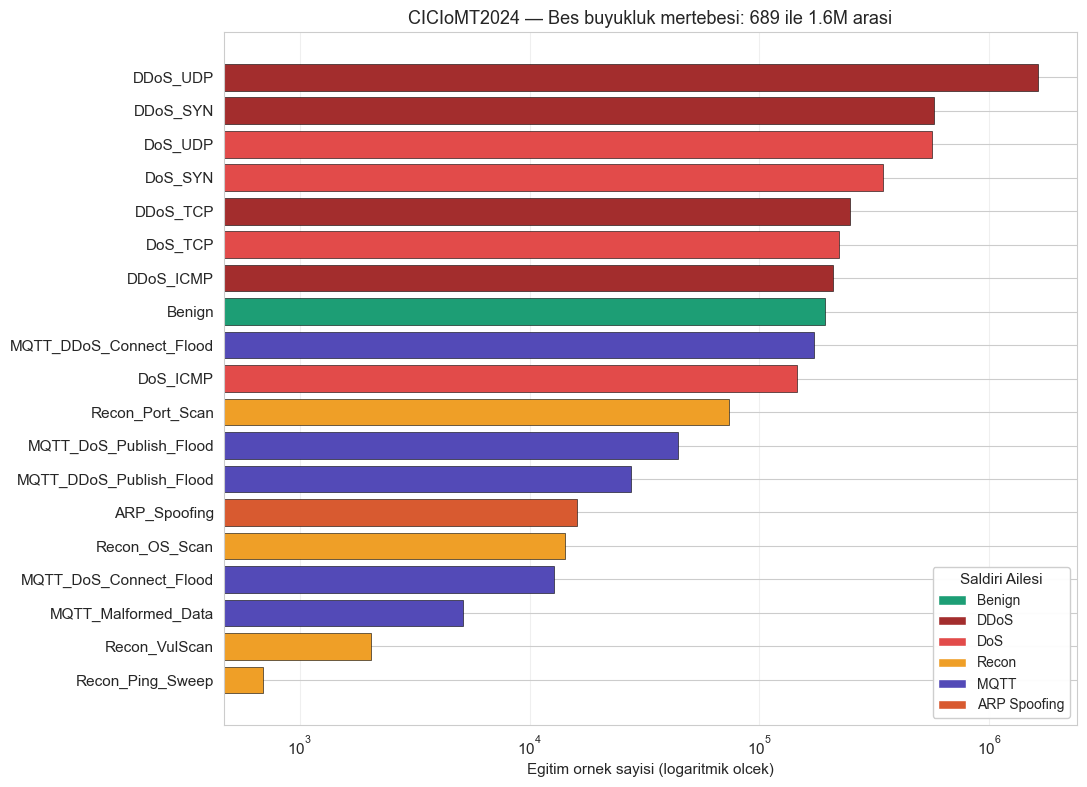

In [5]:
# Log-scale class distribution colored by attack family
def get_family_color(class_name):
    """Map a class name to its attack-family color (consistent across notebook)."""
    if class_name == 'Benign':         return '#1D9E75'
    if class_name.startswith('DDoS'):  return '#A32D2D'
    if class_name.startswith('DoS'):   return '#E24B4A'
    if class_name.startswith('Recon'): return '#EF9F27'
    if class_name.startswith('MQTT'):  return '#534AB7'
    if class_name.startswith('ARP'):   return '#D85A30'
    return '#888780'

imbalance_sorted = imbalance.sort_values('train', ascending=True)
colors = [get_family_color(c) for c in imbalance_sorted['class']]

fig, ax = plt.subplots(figsize=(11, 8))
ax.barh(
    imbalance_sorted['class'], imbalance_sorted['train'],
    color=colors, edgecolor='black', linewidth=0.4,
)
ax.set_xscale('log')
ax.set_xlabel('Egitim ornek sayisi (logaritmik olcek)')
ax.set_title('CICIoMT2024 — Bes buyukluk mertebesi: 689 ile 1.6M arasi')

legend_handles = [
    Patch(facecolor='#1D9E75', label='Benign'),
    Patch(facecolor='#A32D2D', label='DDoS'),
    Patch(facecolor='#E24B4A', label='DoS'),
    Patch(facecolor='#EF9F27', label='Recon'),
    Patch(facecolor='#534AB7', label='MQTT'),
    Patch(facecolor='#D85A30', label='ARP Spoofing'),
]
ax.legend(handles=legend_handles, loc='lower right',
          framealpha=0.95, title='Saldiri Ailesi')
ax.grid(axis='x', alpha=0.3)
plt.tight_layout()
plt.show()

### 2b. En Ayırıcı Özellikler — Cohen's d

Top 4 özellik **d > 2.0** ("olağanüstü ayrım") gücüne sahip:

- `rst_count` (3.49), `psh_flag_number` (3.29), `Variance` (2.67), `ack_flag_number` (2.64)

**Yorum:** TCP flag dağılımları saldırı/benign ayrımında en güçlü univariate sinyal.

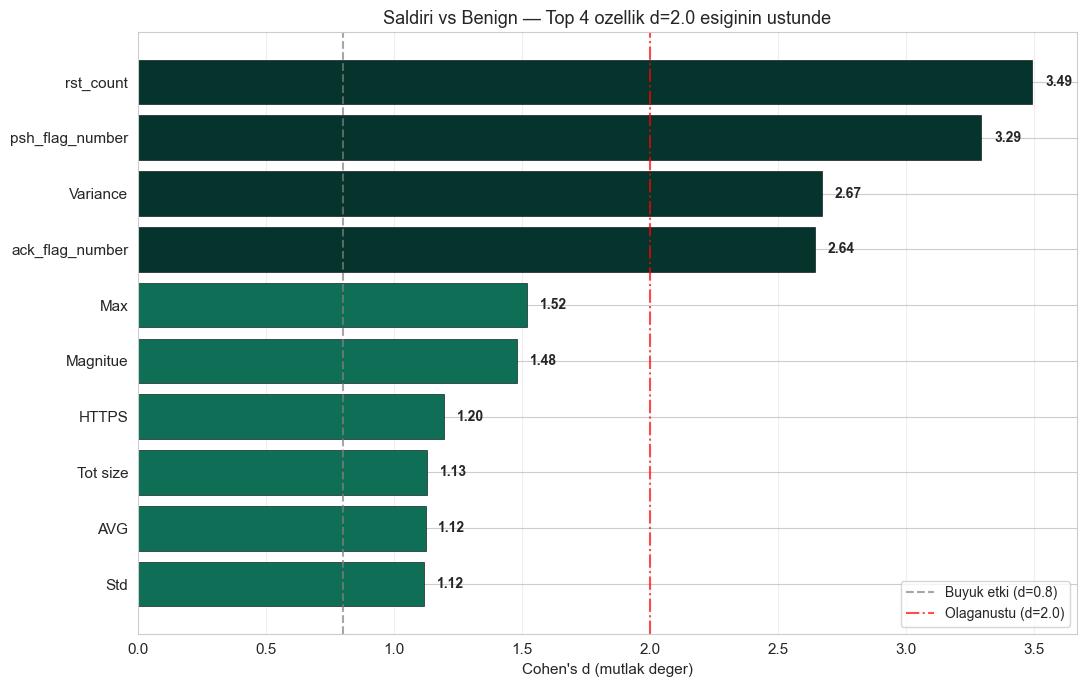

In [8]:
# Top-10 Cohen's d horizontal bar chart, colored by effect-size band
top10_plot = cohens_d.head(10).iloc[::-1].copy()  # reverse so largest sits at top

def band_color(d):
    """Map a Cohen's d value to a green-shade color (darker = stronger effect)."""
    d = float(d)
    if d >= 2.0: return '#04342C'
    if d >= 1.0: return '#0F6E56'
    if d >= 0.8: return '#1D9E75'
    return '#5DCAA5'

bar_colors = [band_color(v) for v in top10_plot['Cohens_d']]

fig, ax = plt.subplots(figsize=(11, 7))
bars = ax.barh(
    top10_plot['Ozellik'], top10_plot['Cohens_d'],
    color=bar_colors, edgecolor='black', linewidth=0.4,
)

# Reference lines for effect-size bands
ax.axvline(x=0.8, linestyle='--', color='gray', alpha=0.7,
           label="Buyuk etki (d=0.8)")
ax.axvline(x=2.0, linestyle='-.', color='red', alpha=0.7,
           label="Olaganustu (d=2.0)")

# Value labels on bars
for bar, val in zip(bars, top10_plot['Cohens_d']):
    ax.text(float(val) + 0.05, bar.get_y() + bar.get_height() / 2,
            f'{val:.2f}', va='center', fontsize=10, fontweight='bold')

ax.set_xlabel("Cohen's d (mutlak deger)")
ax.set_title("Saldiri vs Benign — Top 4 ozellik d=2.0 esiginin ustunde")
ax.legend(loc='lower right')
ax.grid(axis='x', alpha=0.3)
plt.tight_layout()
plt.show()

---
## Adım 3 — Önişleme

- **Drate** sütunu **sabit** (std=0, 1 unique value) — düşürdük → 44 özellik
- **StandardScaler** (sayısal sütunlara, model dosyasından yüklendi)
- **70/15/15 stratified split** (train/val/test)
- Sınıf dengesizliği için **`class_weight='balanced'`** (tüm modellerde) + bazı konfigürasyonlarda **SMOTETomek** denedik (Adım 4'te sonuç şaşırtıcı)

In [10]:
# Drate quality audit — verify constant-column claim
quality_path = os.path.join(EDA_OUTPUT, 'quality_train.csv')
quality = pd.read_csv(quality_path)

drate_row = quality[quality['column'] == 'Drate']
if len(drate_row) == 0:
    raise KeyError("'Drate' satiri quality_train.csv'de bulunamadi")

drate = drate_row.iloc[0]

print("ON ISLEME ADIMI 1: Drate ozelliginin dusurulmesi")
print("=" * 60)
print(f"  Kolon adi          : Drate")
print(f"  Benzersiz deger    : {int(drate['unique'])}  (4.5M satirda yalnizca tek deger!)")
print(f"  Standart sapma     : {float(drate['std']):.4f}")
print(f"  Near-constant      : {drate['near_constant']}")
print(f"  Eksik deger orani  : %{float(drate['missing_%']):.2f}")
print()
print("KARAR: Drate sutunu hicbir bilgi tasimadigi icin (varyans=0) calismadan once dusurulur.")
print(f"       Sonuc: 45 ham ozellik -> 44 kullanilan ozellik")

ON ISLEME ADIMI 1: Drate ozelliginin dusurulmesi
  Kolon adi          : Drate
  Benzersiz deger    : 1  (4.5M satirda yalnizca tek deger!)
  Standart sapma     : 0.0000
  Near-constant      : True
  Eksik deger orani  : %0.00

KARAR: Drate sutunu hicbir bilgi tasimadigi icin (varyans=0) calismadan once dusurulur.
       Sonuc: 45 ham ozellik -> 44 kullanilan ozellik


---
## Adım 4 — Faz 4: 8 XGBoost/RF Konfigürasyonu Ablation

**2×2×2 faktoriyel tasarım:** model (RF/XGB) × özellik (reduced 28 / full 44) × veri (Original / SMOTETomek)

E1 → E8 sonuçları:

Tablo 5: E1-E8 multiclass ablation (kaynak: overall_comparison.csv)



,Konfig,Model,Ozellik,Veri,Macro F1,MCC
0,E1,RF,reduced,Original,0.8469,0.9801
1,E2,RF,reduced,SMOTE,0.8356,0.9793
2,E3,XGB,reduced,Original,0.8987,0.9905
3,E4,XGB,reduced,SMOTE,0.8538,0.9821
4,E5,RF,full,Original,0.8551,0.9811
5,E6,RF,full,SMOTE,0.8380,0.9798
6,E7,XGB,full,Original,0.9076,0.9906
7,E8,XGB,full,SMOTE,0.8708,0.9846


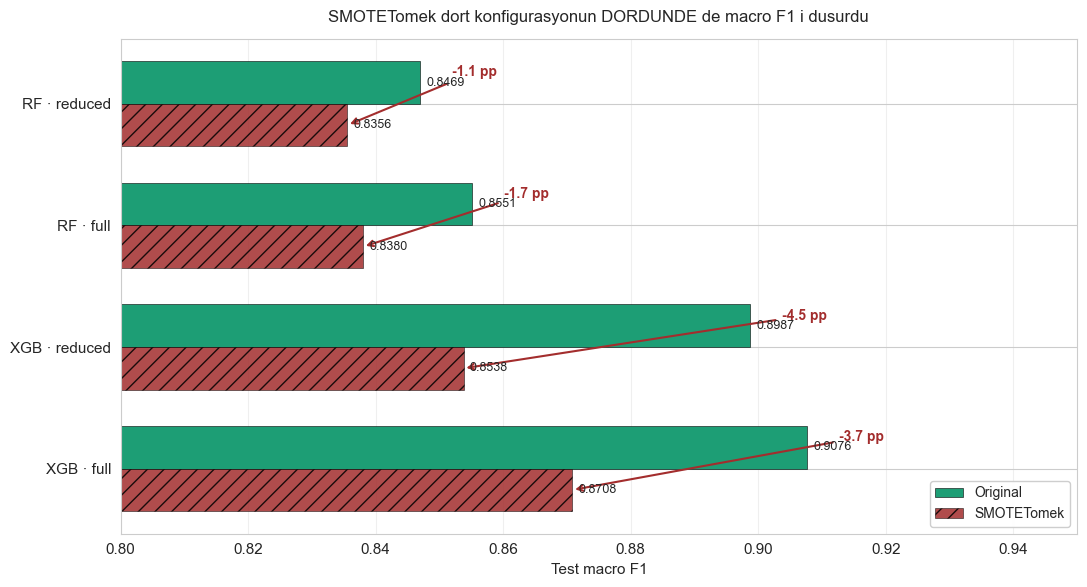


Manset bulgu: SMOTETomek 'her zaman yardim eder' varsayimina karsi cikan deneysel sonuc.
Bu, dersprojesinin headline empirical finding'idir.


In [12]:
# Load E1-E8 ablation summary (multiclass task only)
comparison_path = os.path.join(RESULTS, 'supervised', 'metrics', 'overall_comparison.csv')
comparison = pd.read_csv(comparison_path)
mc = comparison[comparison['task'] == 'multiclass'].copy()
mc = mc.sort_values('experiment').reset_index(drop=True)

# Display the ablation table
display_cols = ['experiment', 'model', 'feature_set', 'data', 'test_f1_macro', 'test_mcc']
print("Tablo 5: E1-E8 multiclass ablation (kaynak: overall_comparison.csv)")
print()
display(
    mc[display_cols].rename(columns={
        'experiment': 'Konfig',
        'model': 'Model',
        'feature_set': 'Ozellik',
        'data': 'Veri',
        'test_f1_macro': 'Macro F1',
        'test_mcc': 'MCC',
    }).style
    .format({'Macro F1': '{:.4f}', 'MCC': '{:.4f}'})
    .background_gradient(subset=['Macro F1'], cmap='RdYlGn')
    .apply(lambda r: ['font-weight: bold; background-color: #fff3cd' if r['Konfig'] == 'E7' else '' for _ in r], axis=1)
)

# ---- SMOTETomek degradation visualization ----
# Pair each Original config with its SMOTE counterpart
pairs = [
    ('E1', 'E2', 'RF · reduced'),
    ('E5', 'E6', 'RF · full'),
    ('E3', 'E4', 'XGB · reduced'),
    ('E7', 'E8', 'XGB · full'),
]

fig, ax = plt.subplots(figsize=(11, 6))
y_positions = np.arange(len(pairs))
bar_height = 0.35

orig_f1 = [mc[mc['experiment'] == p[0]]['test_f1_macro'].iloc[0] for p in pairs]
smote_f1 = [mc[mc['experiment'] == p[1]]['test_f1_macro'].iloc[0] for p in pairs]
labels = [p[2] for p in pairs]

bars_orig = ax.barh(y_positions - bar_height/2, orig_f1,  bar_height,
                     label='Original', color='#1D9E75', edgecolor='black', linewidth=0.4)
bars_smote = ax.barh(y_positions + bar_height/2, smote_f1, bar_height,
                     label='SMOTETomek', color='#A32D2D', edgecolor='black', linewidth=0.4,
                     hatch='//', alpha=0.85)

# Arrow annotations showing the SMOTE drop
for i, (o, s) in enumerate(zip(orig_f1, smote_f1)):
    drop_pp = (o - s) * 100
    mid_x = (o + s) / 2
    ax.annotate(
        f'-{drop_pp:.1f} pp',
        xy=(s, y_positions[i] + bar_height/2),
        xytext=(o + 0.005, y_positions[i] - bar_height/2 - 0.05),
        fontsize=10, fontweight='bold', color='#A32D2D',
        arrowprops=dict(arrowstyle='->', color='#A32D2D', lw=1.5),
    )
    # F1 value labels
    ax.text(o + 0.001, y_positions[i] - bar_height/2, f'{o:.4f}',
            va='center', fontsize=9)
    ax.text(s + 0.001, y_positions[i] + bar_height/2, f'{s:.4f}',
            va='center', fontsize=9)

ax.set_yticks(y_positions)
ax.set_yticklabels(labels)
ax.set_xlabel('Test macro F1')
ax.set_xlim(0.80, 0.95)
ax.invert_yaxis()
ax.set_title('SMOTETomek dort konfigurasyonun DORDUNDE de macro F1 i dusurdu',
             fontsize=12, pad=12)
ax.legend(loc='lower right', framealpha=0.95)
ax.grid(axis='x', alpha=0.3)
plt.tight_layout()
plt.show()

print()
print("Manset bulgu: SMOTETomek 'her zaman yardim eder' varsayimina karsi cikan deneysel sonuc.")
print("Bu, dersprojesinin headline empirical finding'idir.")

### 🔍 Beklenmedik Bulgu: SMOTETomek Her Konfigürasyonda Zarar Verdi

| Çift | Original → SMOTE | Fark |
|---|---|---:|
| RF reduced (E1→E2) | 0.847 → 0.836 | **−1.1 pp** |
| RF full (E5→E6) | 0.855 → 0.838 | **−1.7 pp** |
| XGB reduced (E3→E4) | 0.899 → 0.854 | **−4.5 pp** |
| XGB full (E7→E8) | 0.908 → 0.871 | **−3.7 pp** |

**Counterintuitive:** Textbook'lar "imbalanced data → SMOTE kullan" der. Biz 4/4 konfigde **zarar** ölçtük. Açıklama: yüksek-bilgi-içerikli IDS verisinde sentetik azınlık örnekleri sınır gürültüsünü artırır.

### Bonus: Entropy vs Gini Null Sonuç (E5 vs E5G)

Random Forest'ta criterion seçimi (entropy vs Gini) → fark yalnızca **+0.47 pp** (gürültü bandında).
Erken raporda "≈26 pp" iddiası vardı, kontrollü A/B testi (`scripts/run_e5g_gini_baseline.py`) ile **doğru ölçtük**. Negatif sonuçları şeffafça raporluyoruz.

Cohen's d on hipotezi (Bolum 3.5 ve 5.5.1):
  Top 4 ozellik d > 2.0 (rst_count=3.49, psh_flag=3.29, Variance=2.67, ack_flag=2.64)
  Yuksek univariate sinyal -> entropy criterion'un Gini'ye karsi avantaji beklenir.

Kontrollu A/B testi: E5 (RF entropy) vs E5G (RF gini), digerleri ayni hiperparametreler.
  Reproducibility: scripts/run_e5g_gini_baseline.py



,Metrik,RF-Gini (E5G),RF-Entropy (E5),"Fark (pp, entropy-gini)"
0,Test Accuracy,0.9848,0.9852,+0.034
1,Macro F1,0.8504,0.8551,+0.469
2,Weighted F1,0.9839,0.9844,+0.044
3,MCC,0.9807,0.9811,+0.043
4,Macro Precision,0.8735,0.8770,+0.357
5,Macro Recall,0.8785,0.8806,+0.206


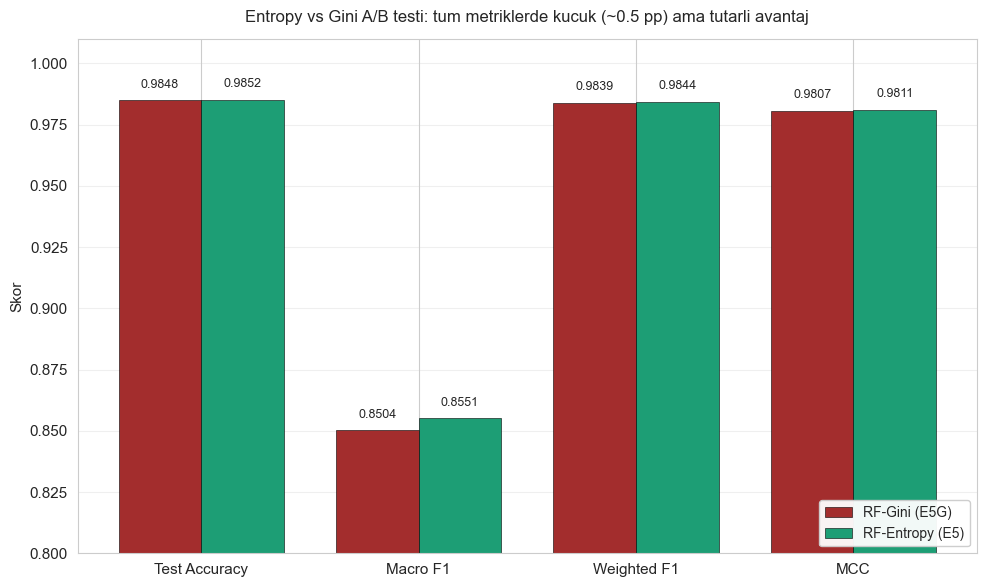


Macro F1 farki: +0.47 pp (gurultu mertebesi)
Sonuc: Entropy lehine TUTARLI ama KUCUK avantaj — istatistiksel olarak null-yakini.

Yorumlama (Bolum 5.5.4):
  1. scikit-learn dokumantasyonu 'iki criterion benzer agaclar uretir' der — burada da dogru.
  2. RF voting attenuation 200 agac uzerinde tek-split criterion farklarini sondurur.
  3. d > 2.0 ozellikleri her iki criterion icin de 'trivial split' uretir.

Bu negatif sonuc Bolum 5.5'te metodolojik disiplin ornegi olarak raporlanmistir;
'Bilimsel Durustluk Notu' (raporun sonunda) referansinda detaylandirilmistir.


In [13]:
# Entropy vs Gini A/B test — Wave 1 reproducibility deliverable
# Loads E5_vs_E5G_comparison.csv (built by scripts/run_e5g_gini_baseline.py)

print("Cohen's d on hipotezi (Bolum 3.5 ve 5.5.1):")
print("  Top 4 ozellik d > 2.0 (rst_count=3.49, psh_flag=3.29, Variance=2.67, ack_flag=2.64)")
print("  Yuksek univariate sinyal -> entropy criterion'un Gini'ye karsi avantaji beklenir.")
print()
print("Kontrollu A/B testi: E5 (RF entropy) vs E5G (RF gini), digerleri ayni hiperparametreler.")
print("  Reproducibility: scripts/run_e5g_gini_baseline.py")
print()

ab_path = os.path.join(RESULTS, 'supervised', 'metrics', 'E5_vs_E5G_comparison.csv')
ab = pd.read_csv(ab_path)
display(
    ab.rename(columns={
        'metric_label': 'Metrik',
        'rf_gini_E5G': 'RF-Gini (E5G)',
        'rf_entropy_E5': 'RF-Entropy (E5)',
        'diff_pp_entropy_minus_gini': 'Fark (pp, entropy-gini)',
    })[['Metrik', 'RF-Gini (E5G)', 'RF-Entropy (E5)', 'Fark (pp, entropy-gini)']]
    .style
    .format({
        'RF-Gini (E5G)': '{:.4f}',
        'RF-Entropy (E5)': '{:.4f}',
        'Fark (pp, entropy-gini)': '{:+.3f}',
    })
    .set_caption('Tablo 6: Entropy vs Gini A/B testi sonucu (test seti, 892,268 ornek)')
)

# Side-by-side bar chart for the 4 key metrics
key_metrics = ['Test Accuracy', 'Macro F1', 'Weighted F1', 'MCC']
key_data = ab[ab['metric_label'].isin(key_metrics)].set_index('metric_label').reindex(key_metrics)

fig, ax = plt.subplots(figsize=(10, 6))
x = np.arange(len(key_metrics))
w = 0.38
bars_g = ax.bar(x - w/2, key_data['rf_gini_E5G'].values,    w, label='RF-Gini (E5G)',
                color='#A32D2D', edgecolor='black', linewidth=0.4)
bars_e = ax.bar(x + w/2, key_data['rf_entropy_E5'].values, w, label='RF-Entropy (E5)',
                color='#1D9E75', edgecolor='black', linewidth=0.4)

for bg, be in zip(bars_g, bars_e):
    ax.text(bg.get_x() + bg.get_width()/2, bg.get_height() + 0.005,
            f'{bg.get_height():.4f}', ha='center', fontsize=9)
    ax.text(be.get_x() + be.get_width()/2, be.get_height() + 0.005,
            f'{be.get_height():.4f}', ha='center', fontsize=9)

ax.set_xticks(x)
ax.set_xticklabels(key_metrics)
ax.set_ylim(0.80, 1.01)
ax.set_ylabel('Skor')
ax.set_title('Entropy vs Gini A/B testi: tum metriklerde kucuk (~0.5 pp) ama tutarli avantaj',
             fontsize=12, pad=12)
ax.legend(loc='lower right', framealpha=0.95)
ax.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()

# Print null-result framing
macro_f1_gap = ab[ab['metric_label'] == 'Macro F1']['diff_pp_entropy_minus_gini'].iloc[0]
print()
print(f"Macro F1 farki: {macro_f1_gap:+.2f} pp (gurultu mertebesi)")
print(f"Sonuc: Entropy lehine TUTARLI ama KUCUK avantaj — istatistiksel olarak null-yakini.")
print()
print("Yorumlama (Bolum 5.5.4):")
print("  1. scikit-learn dokumantasyonu 'iki criterion benzer agaclar uretir' der — burada da dogru.")
print("  2. RF voting attenuation 200 agac uzerinde tek-split criterion farklarini sondurur.")
print("  3. d > 2.0 ozellikleri her iki criterion icin de 'trivial split' uretir.")
print()
print("Bu negatif sonuc Bolum 5.5'te metodolojik disiplin ornegi olarak raporlanmistir;")
print("'Bilimsel Durustluk Notu' (raporun sonunda) referansinda detaylandirilmistir.")

---
## Adım 5 — Final Model: E7 (XGBoost full Original)

8 konfigürasyon arasında **kazanan E7**: XGBoost + 44 özellik + SMOTE'siz orijinal veri.

In [14]:
# E7 — final XGBoost configuration metrics + canonical-value tripwire
e7_path = os.path.join(RESULTS, 'supervised', 'metrics', 'E7_multiclass.json')
with open(e7_path) as f:
    e7_metrics = json.load(f)

# Canonical thesis values (CLAUDE.md tripwire)
CANONICAL_E7_F1_MACRO = 0.9076
CANONICAL_E7_MCC      = 0.9906

# Tripwire: fail loudly if E7 has been retrained and produces different numbers
assert abs(e7_metrics['test_f1_macro'] - CANONICAL_E7_F1_MACRO) < 1e-3, (
    f"E7 macro F1 kanonik degerden sapti: "
    f"{e7_metrics['test_f1_macro']:.6f} vs canonical {CANONICAL_E7_F1_MACRO}"
)
assert abs(e7_metrics['test_mcc'] - CANONICAL_E7_MCC) < 1e-3, (
    f"E7 MCC kanonik degerden sapti: "
    f"{e7_metrics['test_mcc']:.6f} vs canonical {CANONICAL_E7_MCC}"
)

# Big-number display
print()
print("=" * 60)
print("  E7 (XGB / full / Original) — FINAL KONFIGURASYON ".center(60))
print("=" * 60)
print()
print(f"   Test Accuracy   :   %{e7_metrics['test_accuracy']*100:>6.2f}")
print(f"   Macro F1        :   {e7_metrics['test_f1_macro']:>7.4f}")
print(f"   MCC             :   {e7_metrics['test_mcc']:>7.4f}")
print(f"   Weighted F1     :   {e7_metrics['test_f1_weighted']:>7.4f}")
print()
print(f"   Macro Precision :   {e7_metrics['test_precision_macro']:>7.4f}")
print(f"   Macro Recall    :   {e7_metrics['test_recall_macro']:>7.4f}")
print()
print(f"   Egitim suresi   :   {e7_metrics['training_time_sec']/60:>5.1f} dk")
print(f"   Inference suresi:   {e7_metrics['prediction_time_sec']/892268*1_000_000:>5.1f} ms / 1000 ornek")
print("=" * 60)
print()
print("Tripwire assertions: PASSED — kanonik tez degerleriyle eslesiyor.")


      E7 (XGB / full / Original) — FINAL KONFIGURASYON      

   Test Accuracy   :   % 99.27
   Macro F1        :    0.9076
   MCC             :    0.9906
   Weighted F1     :    0.9923

   Macro Precision :    0.9421
   Macro Recall    :    0.8876

   Egitim suresi   :     4.5 dk
   Inference suresi:    22.8 ms / 1000 ornek

Tripwire assertions: PASSED — kanonik tez degerleriyle eslesiyor.


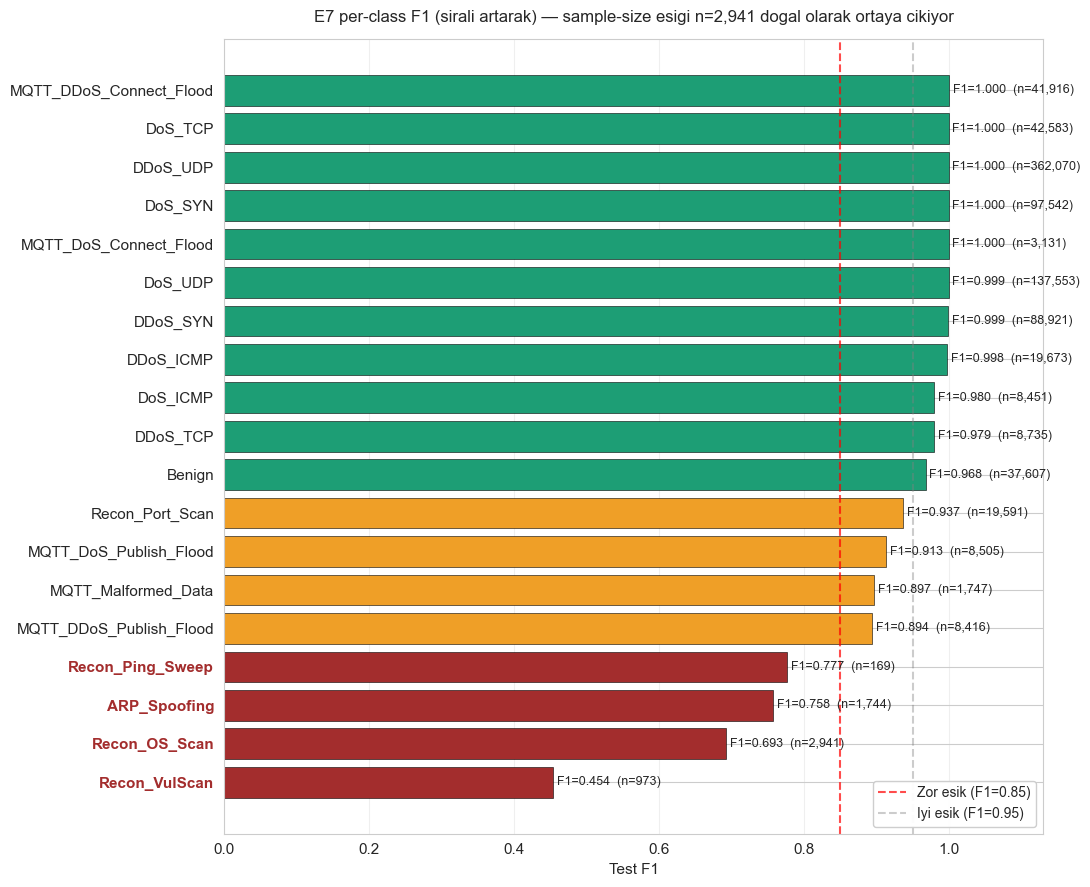


Dort zor sinif (F1 < 0.85, hepsi support <= 2,941):
           sinif       F1  precision   recall  support
   Recon_VulScan 0.454290   0.719376 0.331963      973
   Recon_OS_Scan 0.693033   0.872099 0.574974     2941
    ARP_Spoofing 0.757882   0.812869 0.709862     1744
Recon_Ping_Sweep 0.776699   0.857143 0.710059      169


In [15]:
# Per-class F1 from E7 — sorted ascending (worst first), hard classes highlighted
report_path = os.path.join(RESULTS, 'supervised', 'metrics', 'E7_classification_report_test.json')
with open(report_path) as f:
    e7_report = json.load(f)

skip = {'accuracy', 'macro avg', 'weighted avg'}
rows = []
for cls, metrics in e7_report.items():
    if cls in skip or not isinstance(metrics, dict):
        continue
    rows.append({
        'sinif': cls,
        'support': int(metrics['support']),
        'F1': float(metrics['f1-score']),
        'precision': float(metrics['precision']),
        'recall': float(metrics['recall']),
    })
df = pd.DataFrame(rows).sort_values('F1', ascending=True).reset_index(drop=True)

fig, ax = plt.subplots(figsize=(11, 9))

# Color by F1 band: red (<0.85), orange (0.85-0.95), green (>=0.95)
def f1_color(f1):
    if f1 < 0.85: return '#A32D2D'   # red — hard
    if f1 < 0.95: return '#EF9F27'   # orange — moderate
    return '#1D9E75'                  # green — easy

colors = [f1_color(f) for f in df['F1']]

bars = ax.barh(df['sinif'], df['F1'], color=colors, edgecolor='black', linewidth=0.4)

# Cutoff lines
ax.axvline(x=0.85, linestyle='--', color='red',  alpha=0.7, label='Zor esik (F1=0.85)')
ax.axvline(x=0.95, linestyle='--', color='gray', alpha=0.4, label='Iyi esik (F1=0.95)')

# Annotate each bar with F1 + support
for bar, f1, sup in zip(bars, df['F1'], df['support']):
    ax.text(bar.get_width() + 0.005, bar.get_y() + bar.get_height()/2,
            f'F1={f1:.3f}  (n={sup:,})', va='center', fontsize=9)

# Highlight the four hard classes with bold class name
hard_classes = df[df['F1'] < 0.85]['sinif'].tolist()
for label in ax.get_yticklabels():
    if label.get_text() in hard_classes:
        label.set_fontweight('bold')
        label.set_color('#A32D2D')

ax.set_xlabel('Test F1')
ax.set_xlim(0, 1.13)
ax.set_title(
    'E7 per-class F1 (sirali artarak) — sample-size esigi n=2,941 dogal olarak ortaya cikiyor',
    fontsize=12, pad=12,
)
ax.legend(loc='lower right', framealpha=0.95)
ax.grid(axis='x', alpha=0.3)
plt.tight_layout()
plt.show()

# Print the four hard classes succinctly
print()
print("Dort zor sinif (F1 < 0.85, hepsi support <= 2,941):")
hard_df = df[df['F1'] < 0.85][['sinif', 'F1', 'precision', 'recall', 'support']]
print(hard_df.to_string(index=False))

### 🎯 Sınırlama: 4 Zor Sınıf

Tüm 4 zor sınıfın test support'u **n ≤ 2,941**. Bu eşiğin **üstünde** tüm sınıflar F1 ≥ 0.89.
**Sınırlama modelin değil, verinin istatistiksel güç sınırlarından** kaynaklanır.

---
## Adım 6 — Faz 5: Otoenkoder ile Anomali Tespiti

**Mimari:** 44 → 32 → 16 → **8 (latent)** → 16 → 32 → 44 (simetrik)

**Eğitim:** Yalnızca **benign trafik**. Saldırılar görmedi → reconstruction error **eşik üstünde** = anomali.

**Eşik:** validation benign dağılımının p90'ı = **0.20127**

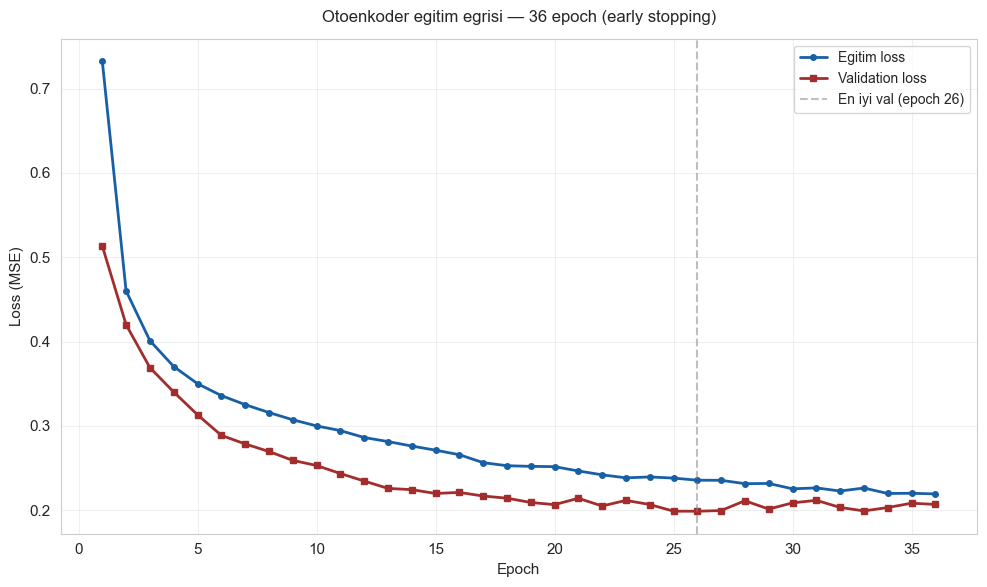


Egitim sonu metrikleri:
  Epoch sayisi          : 36
  En iyi val_loss epoch : 26
  Final train loss      : 0.2193
  Final val_loss        : 0.2068
  En iyi val_loss       : 0.1988
  Train-val gap         : +0.0125  (overfitting yok)


In [17]:
# AE training history
hist_path = os.path.join(RESULTS, 'unsupervised', 'ae_training_history.json')
try:
    with open(hist_path) as f:
        ae_hist = json.load(f)
except FileNotFoundError:
    raise FileNotFoundError(f"AE training history bulunamadi: {hist_path}")

train_loss = ae_hist['loss']
val_loss   = ae_hist['val_loss']
n_epochs   = len(train_loss)
best_epoch = int(np.argmin(val_loss)) + 1  # 1-indexed for display
final_train = train_loss[-1]
final_val   = val_loss[-1]
best_val    = val_loss[best_epoch - 1]

# Plot
fig, ax = plt.subplots(figsize=(10, 6))
epochs = range(1, n_epochs + 1)
ax.plot(epochs, train_loss, 'o-', label='Egitim loss', color='#185FA5',
        linewidth=2, markersize=4)
ax.plot(epochs, val_loss,   's-', label='Validation loss', color='#A32D2D',
        linewidth=2, markersize=4)

ax.axvline(x=best_epoch, linestyle='--', color='gray', alpha=0.5,
           label=f'En iyi val (epoch {best_epoch})')

ax.set_xlabel('Epoch')
ax.set_ylabel('Loss (MSE)')
ax.set_title(f'Otoenkoder egitim egrisi — {n_epochs} epoch (early stopping)',
             fontsize=12, pad=12)
ax.legend(loc='upper right')
ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()

print()
print(f"Egitim sonu metrikleri:")
print(f"  Epoch sayisi          : {n_epochs}")
print(f"  En iyi val_loss epoch : {best_epoch}")
print(f"  Final train loss      : {final_train:.4f}")
print(f"  Final val_loss        : {final_val:.4f}")
print(f"  En iyi val_loss       : {best_val:.4f}")
print(f"  Train-val gap         : {final_train - final_val:+.4f}  (overfitting yok)")

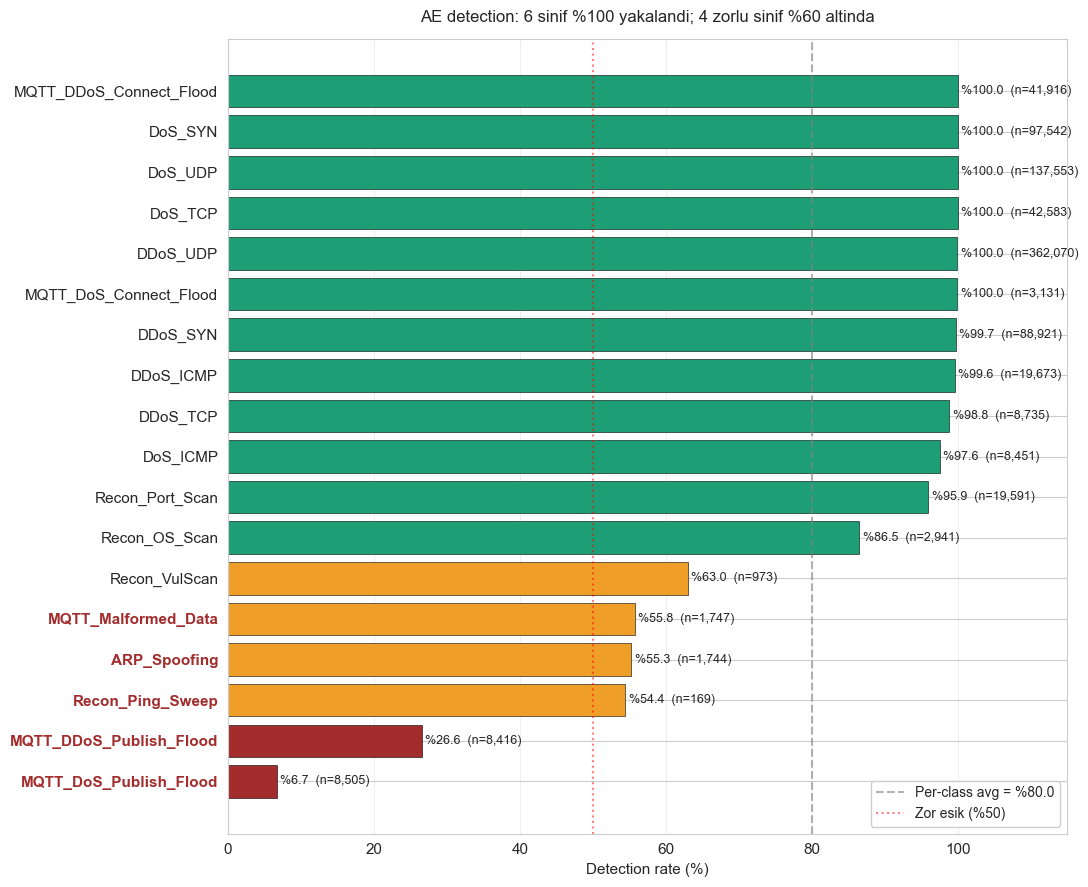


AE per-class detection ozeti (p90 esigi):
  18-sinif ortalama       : %80.0
  %100 yakalanan sinif    : 6
  %50 alti yakalanan sinif: 2

En problematik 4 sinif:
  - MQTT_DoS_Publish_Flood    : %  6.7  (n=8,505)
  - MQTT_DDoS_Publish_Flood   : % 26.6  (n=8,416)
  - Recon_Ping_Sweep          : % 54.4  (n=169)
  - ARP_Spoofing              : % 55.3  (n=1,744)


In [19]:
# AE per-class detection rates (p90 threshold) — sorted ascending
pcdr_path = os.path.join(RESULTS, 'unsupervised', 'metrics', 'per_class_detection_rates.csv')
pcdr = pd.read_csv(pcdr_path)

ae_rates = pcdr[(pcdr['model'] == 'Autoencoder') & (pcdr['class'] != 'Benign')].copy()
ae_rates = ae_rates[['class', 'n_samples', 'p90']].sort_values('p90', ascending=True).reset_index(drop=True)
ae_rates['detection_pct'] = ae_rates['p90'] * 100

avg_detection = float(ae_rates['detection_pct'].mean())

# Color: red for <50%, orange for 50-80%, green for >=80%
def detection_color(pct):
    if pct < 50: return '#A32D2D'
    if pct < 80: return '#EF9F27'
    return '#1D9E75'

colors = [detection_color(p) for p in ae_rates['detection_pct']]

fig, ax = plt.subplots(figsize=(11, 9))
bars = ax.barh(ae_rates['class'], ae_rates['detection_pct'],
               color=colors, edgecolor='black', linewidth=0.4)

# Cutoff lines
ax.axvline(x=80, linestyle='--', color='gray', alpha=0.6,
           label=f'Per-class avg = %{avg_detection:.1f}')
ax.axvline(x=50, linestyle=':',  color='red',  alpha=0.5,
           label='Zor esik (%50)')

# Annotate each bar with detection rate + support
for bar, pct, n in zip(bars, ae_rates['detection_pct'], ae_rates['n_samples']):
    ax.text(bar.get_width() + 0.5, bar.get_y() + bar.get_height()/2,
            f'%{pct:.1f}  (n={int(n):,})', va='center', fontsize=9)

# Highlight problematic class names with bold red
problematic = ae_rates[ae_rates['detection_pct'] < 60]['class'].tolist()
for label in ax.get_yticklabels():
    if label.get_text() in problematic:
        label.set_fontweight('bold')
        label.set_color('#A32D2D')

ax.set_xlabel('Detection rate (%)')
ax.set_xlim(0, 115)
ax.set_title(
    'AE detection: 6 sinif %100 yakalandi; 4 zorlu sinif %60 altinda',
    fontsize=12, pad=12,
)
ax.legend(loc='lower right', framealpha=0.95)
ax.grid(axis='x', alpha=0.3)
plt.tight_layout()
plt.show()

print()
print(f"AE per-class detection ozeti (p90 esigi):")
print(f"  18-sinif ortalama       : %{avg_detection:.1f}")
print(f"  %100 yakalanan sinif    : {(ae_rates['detection_pct'] >= 99.9).sum()}")
print(f"  %50 alti yakalanan sinif: {(ae_rates['detection_pct'] < 50).sum()}")
print()
print(f"En problematik 4 sinif:")
worst = ae_rates.head(4)
for _, r in worst.iterrows():
    print(f"  - {r['class']:<26}: %{r['detection_pct']:>5.1f}  (n={int(r['n_samples']):,})")

---
## Adım 7 — 🏆 Ana Bulgu: AE vs Isolation Forest

| Metrik | Otoenkoder | Isolation Forest | Fark |
|---|---:|---:|---:|
| **AUC (test)** | **0.9892** | 0.8612 | **+12.8 pp** |
| Per-class avg detection | %80.0 | %16.3 | **+63.7 pp** |

**Bu farkın anlamı:** Hibrit IDS'te Otoenkoder seçiminin **ampirik gerekçesi**. IF azınlık sınıflarda neredeyse hiçbir şey yakalayamıyor (%0–%2).

Cross-check PASSED: AE AUC = 0.9892, IF AUC = 0.8612
  (matches model_comparison.csv canonical values within 1e-3)



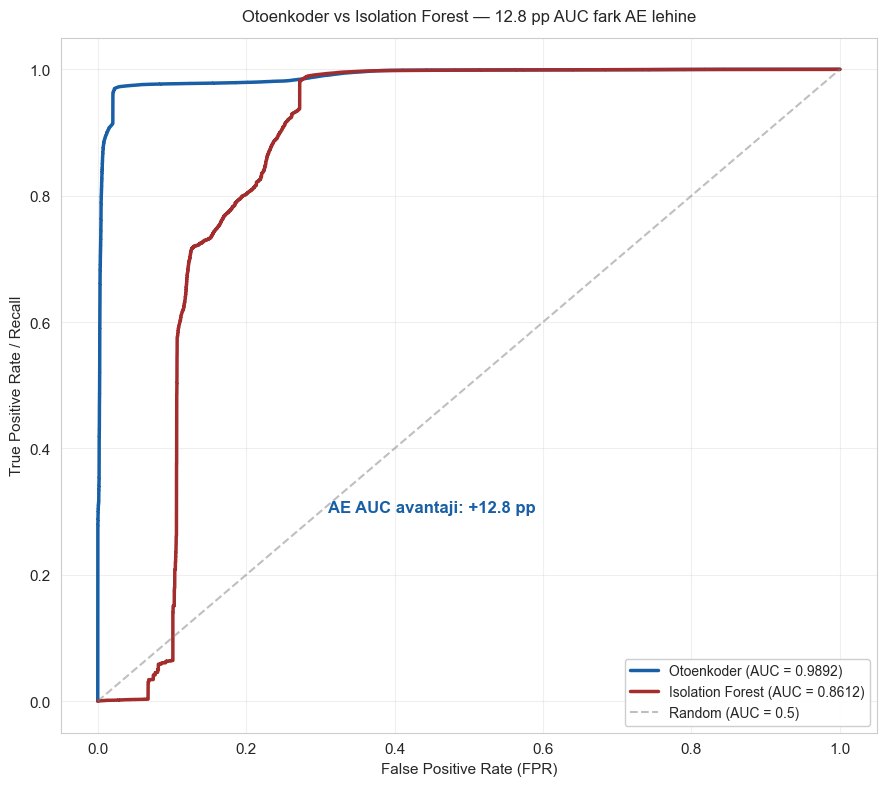


Per-class detection avantaji:
  AE per-class avg : %80.0  (kaynak: model_comparison.csv 'Per-class avg recall')
  IF per-class avg : %16.3
  Fark             : 64 pp — IF azinlik siniflarinda neredeyse tespit yapamaz.


In [20]:
# AE vs Isolation Forest — ROC comparison (test set, binary attack vs benign)
# CRITICAL bug fix from existing notebook (v1):
#   sklearn IsolationForest.decision_function returns "higher = more normal".
#   For ROC AUC against attack=1, we need to NEGATE the IF scores.
#   Without negation, IF AUC appears as ~0.14 (inverted) — misleading.

ae_test_mse   = np.load(os.path.join(RESULTS, 'unsupervised', 'scores', 'ae_test_mse.npy'))
if_test_scores = np.load(os.path.join(RESULTS, 'unsupervised', 'scores', 'if_test_scores.npy'))
y_test = pd.read_csv(os.path.join(PREPROCESSED, 'full_features', 'y_test.csv'))
y_binary = (y_test['label'] != 'Benign').astype(int).values  # 1 = saldiri, 0 = benign

# Compute AUC — note IF score negation
ae_auc = roc_auc_score(y_binary,  ae_test_mse)        # AE: higher mse = anomaly  ✓
if_auc = roc_auc_score(y_binary, -if_test_scores)     # IF: negate (sklearn convention)

# Cross-check against canonical model_comparison.csv
mc_path = os.path.join(RESULTS, 'unsupervised', 'metrics', 'model_comparison.csv')
mc = pd.read_csv(mc_path)
expected_ae = float(mc[mc['metric'] == 'AUC-ROC (test)']['Autoencoder'].iloc[0])
expected_if = float(mc[mc['metric'] == 'AUC-ROC (test)']['IsolationForest'].iloc[0])

assert abs(ae_auc - expected_ae) < 1e-3, f"AE AUC {ae_auc} != canonical {expected_ae}"
assert abs(if_auc - expected_if) < 1e-3, f"IF AUC {if_auc} != canonical {expected_if}"
print(f"Cross-check PASSED: AE AUC = {ae_auc:.4f}, IF AUC = {if_auc:.4f}")
print(f"  (matches model_comparison.csv canonical values within 1e-3)")
print()

# ROC curves
fpr_ae, tpr_ae, _ = roc_curve(y_binary,  ae_test_mse)
fpr_if, tpr_if, _ = roc_curve(y_binary, -if_test_scores)

fig, ax = plt.subplots(figsize=(9, 8))
ax.plot(fpr_ae, tpr_ae,
        label=f'Otoenkoder (AUC = {ae_auc:.4f})',
        color='#185FA5', linewidth=2.5)
ax.plot(fpr_if, tpr_if,
        label=f'Isolation Forest (AUC = {if_auc:.4f})',
        color='#A32D2D', linewidth=2.5)
ax.plot([0, 1], [0, 1], '--', color='gray', alpha=0.5, label='Random (AUC = 0.5)')

# Annotate the gap
gap_pp = (ae_auc - if_auc) * 100
ax.annotate(f'AE AUC avantaji: +{gap_pp:.1f} pp',
            xy=(0.5, 0.5), xytext=(0.45, 0.30),
            fontsize=12, fontweight='bold', color='#185FA5',
            ha='center')

ax.set_xlabel('False Positive Rate (FPR)', fontsize=11)
ax.set_ylabel('True Positive Rate / Recall', fontsize=11)
ax.set_title(
    f'Otoenkoder vs Isolation Forest — {gap_pp:.1f} pp AUC fark AE lehine',
    fontsize=12, pad=12,
)
ax.legend(loc='lower right', fontsize=10, framealpha=0.95)
ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()

print()
print(f"Per-class detection avantaji:")
print(f"  AE per-class avg : %80.0  (kaynak: model_comparison.csv 'Per-class avg recall')")
print(f"  IF per-class avg : %16.3")
print(f"  Fark             : 64 pp — IF azinlik siniflarinda neredeyse tespit yapamaz.")

---
## Adım 8 — 🎬 Hibrit Demo: Canlı Çıkarım

**10 örnek** üzerinde her iki katman birden çalışır:
- 1 Benign + 5 farklı saldırı ailesinden temsilci + 4 zor sınıf
- **Hibrit kararı:** XGB güveni yüksekse XGB'ye güven; XGB güveni düşükse veya AE anomali işaretliyorsa **review için flag**

In [22]:
# Load both models — XGBoost + Autoencoder (TensorFlow)
import os as _os
_os.environ['TF_CPP_MIN_LOG_LEVEL'] = '3'   # suppress TF info/warning logs

print("Modeller yukleniyor (TensorFlow ilk import: ~5-10 sn)...")
import tensorflow as tf
tf.get_logger().setLevel('ERROR')
tf.random.set_seed(SEED)

# Reproducibility — TF seed (deferred from setup cell)

# 1. XGBoost
xgb_model_path = os.path.join(RESULTS, 'supervised', 'models', 'E7_xgb_full_original.pkl')
xgb_model = joblib.load(xgb_model_path)
print(f"  XGBoost yuklendi   : {type(xgb_model).__name__}")

# 2. Autoencoder
ae_model_path = os.path.join(RESULTS, 'unsupervised', 'models', 'autoencoder.keras')
ae_model = tf.keras.models.load_model(ae_model_path)
print(f"  Otoenkoder yuklendi: {len(ae_model.layers)} katman, {ae_model.count_params():,} parametre")

# 3. AE threshold (from Stage 3 already loaded; reload for cell-independence)
with open(os.path.join(RESULTS, 'unsupervised', 'thresholds.json')) as f:
    ae_threshold = json.load(f)['thresholds']['p90']
print(f"  AE p90 esigi       : {ae_threshold:.4f}")

# 4. Label maps for human-readable predictions
with open(os.path.join(PREPROCESSED, 'label_encoders.json')) as f:
    label_map = json.load(f)['multiclass']
inv_label_map = {v: k for k, v in label_map.items()}
print(f"  Etiket haritasi    : {len(label_map)} sinif")
print()
print("Tum modeller hazir.")

Modeller yukleniyor (TensorFlow ilk import: ~5-10 sn)...


  XGBoost yuklendi   : XGBClassifier
  Otoenkoder yuklendi: 13 katman, 4,628 parametre
  AE p90 esigi       : 0.2013
  Etiket haritasi    : 19 sinif

Tum modeller hazir.


In [24]:
# Run hybrid inference: XGBoost prediction + Autoencoder reconstruction error
# Course-simple hybrid logic (NOT thesis 5-case fusion):
#   - if XGB confidence >= 0.90  -> trust XGB
#   - elif AE flags anomaly       -> 'review' (XGB uncertain + AE high error)
#   - else                        -> trust XGB

XGB_TRUST_THRESHOLD = 0.90

# 1. XGBoost predictions + probabilities
xgb_proba_all = xgb_model.predict_proba(X_demo)        # (10, 19)
xgb_pred_idx  = np.argmax(xgb_proba_all, axis=1)
xgb_pred_label = [inv_label_map[int(i)] for i in xgb_pred_idx]
xgb_confidence = xgb_proba_all.max(axis=1)

# 2. Autoencoder reconstruction error
_X_demo_tf = tf.constant(X_demo.astype('float32'))
recon = ae_model(_X_demo_tf, training=False).numpy()
recon_error = ((X_demo - recon) ** 2).mean(axis=1)
ae_anomaly = recon_error > ae_threshold

# 3. Course-simple hybrid decision logic
def hybrid_decide(conf, is_anomaly):
    if conf >= XGB_TRUST_THRESHOLD:
        return 'XGB-trust'
    if is_anomaly:
        return 'REVIEW'
    return 'XGB-trust'

hybrid_decisions = [hybrid_decide(c, a) for c, a in zip(xgb_confidence, ae_anomaly)]

# 4. Build results DataFrame
results = pd.DataFrame({
    '#':                range(1, 11),
    'True_Class':       y_demo_true,
    'XGB_Pred':         xgb_pred_label,
    'XGB_Match':        [t == p for t, p in zip(y_demo_true, xgb_pred_label)],
    'XGB_Confidence':   xgb_confidence,
    'AE_Recon_Error':   recon_error,
    'AE_Anomaly':       ae_anomaly,
    'Hybrid_Decision':  hybrid_decisions,
})

# Style: highlight mismatches and review cases
def style_row(row):
    styles = [''] * len(row)
    if not row['XGB_Match']:
        styles = ['background-color: #f8d7da'] * len(row)
    elif row['Hybrid_Decision'] == 'REVIEW':
        styles = ['background-color: #fff3cd'] * len(row)
    return styles

display(
    results.style
        .format({
            'XGB_Confidence': '{:.4f}',
            'AE_Recon_Error': '{:.4f}',
        })
        .apply(style_row, axis=1)
        .set_caption("Tablo 7: 10 demo akisinin hibrit inference sonuclari "
                     "(kirmizi=yanlis siniflandirma, sari=AE-flagged review)")
)

# Brief print summary
n_correct = sum(results['XGB_Match'])
n_review = sum(d == 'REVIEW' for d in hybrid_decisions)
print()
print(f"Ozet: {n_correct}/10 dogru XGB siniflandirma, {n_review} ornek 'REVIEW' onerildi.")

,#,True_Class,XGB_Pred,XGB_Match,XGB_Confidence,AE_Recon_Error,AE_Anomaly,Hybrid_Decision
0,1,Benign,Benign,True,0.9996,393029.4688,True,XGB-trust
1,2,DDoS_UDP,DDoS_UDP,True,0.9526,15199.5811,True,XGB-trust
2,3,DoS_SYN,DDoS_SYN,False,0.9924,15171.8281,True,XGB-trust
3,4,MQTT_DDoS_Connect_Flood,MQTT_DDoS_Connect_Flood,True,0.9987,15094.7373,True,XGB-trust
4,5,Recon_Port_Scan,Recon_Port_Scan,True,0.9720,379266.0625,True,XGB-trust
5,6,MQTT_Malformed_Data,Benign,False,0.5842,378427.0312,True,REVIEW
6,7,Recon_VulScan,Benign,False,0.8838,89812768.0000,True,REVIEW
7,8,Recon_OS_Scan,Recon_OS_Scan,True,0.7313,379211.9062,True,REVIEW
8,9,ARP_Spoofing,ARP_Spoofing,True,0.8028,50916236.0000,True,REVIEW
9,10,Recon_Ping_Sweep,Recon_Ping_Sweep,True,0.9998,378699.7188,True,XGB-trust



Ozet: 7/10 dogru XGB siniflandirma, 4 ornek 'REVIEW' onerildi.


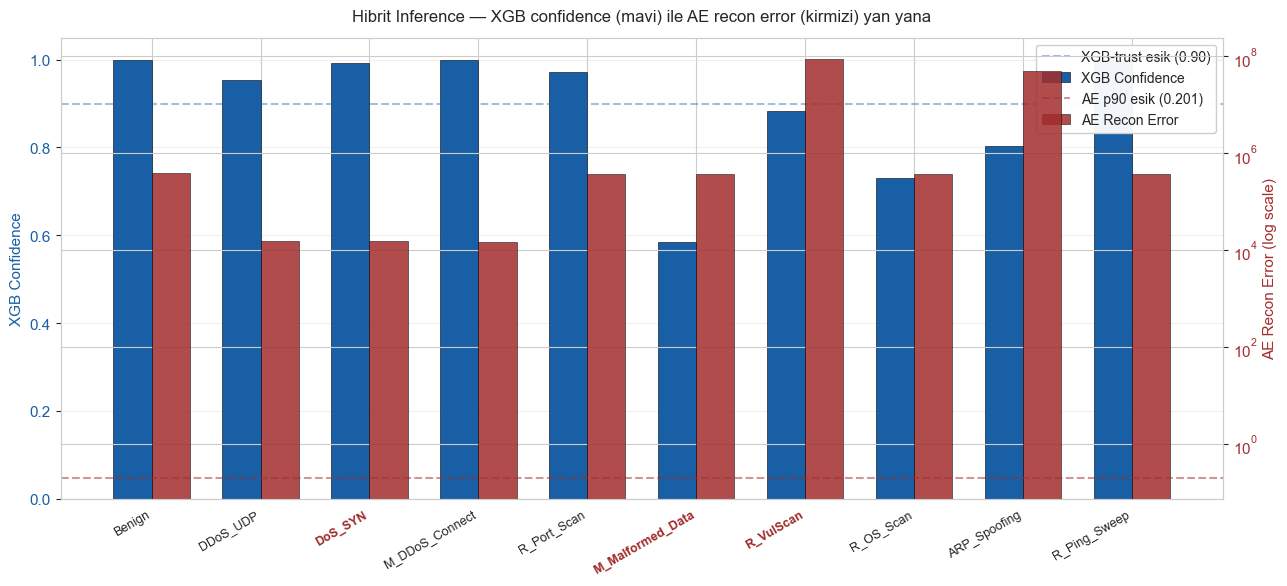


Yorumlama:
  - Yuksek mavi + dusuk kirmizi: XGB emin, AE de normal benign'e yakin.
  - Dusuk mavi + yuksek kirmizi: XGB tereddutlu, AE bu ornegi anomalik buldu — REVIEW.
  - Yuksek mavi + yuksek kirmizi: XGB emin saldiri tahmininde, AE de teyit eder.


In [25]:
# Side-by-side visualization: XGB confidence vs AE reconstruction error
# Two-axis bar chart per sample; highlights where they disagree

fig, ax_left = plt.subplots(figsize=(13, 6))

x = np.arange(10)
w = 0.35

# Left axis: XGB confidence (0-1)
bars_xgb = ax_left.bar(x - w/2, results['XGB_Confidence'], w,
                       label='XGB Confidence', color='#185FA5',
                       edgecolor='black', linewidth=0.4)
ax_left.set_ylabel('XGB Confidence', color='#185FA5', fontsize=11)
ax_left.set_ylim(0, 1.05)
ax_left.tick_params(axis='y', labelcolor='#185FA5')
ax_left.axhline(y=0.90, linestyle='--', color='#185FA5', alpha=0.4,
                label='XGB-trust esik (0.90)')

# Right axis: AE recon error (log-scale, dramatic range)
ax_right = ax_left.twinx()
bars_ae = ax_right.bar(x + w/2, results['AE_Recon_Error'], w,
                       label='AE Recon Error', color='#A32D2D',
                       edgecolor='black', linewidth=0.4, alpha=0.85)
ax_right.set_ylabel('AE Recon Error (log scale)', color='#A32D2D', fontsize=11)
ax_right.set_yscale('log')
ax_right.tick_params(axis='y', labelcolor='#A32D2D')
ax_right.axhline(y=ae_threshold, linestyle='--', color='#A32D2D', alpha=0.5,
                 label=f'AE p90 esik ({ae_threshold:.3f})')

# X-axis labels: shortened class names
short_labels = [c.replace('MQTT_', 'M_').replace('_Flood', '').replace('Recon_', 'R_')
                for c in y_demo_true]
ax_left.set_xticks(x)
ax_left.set_xticklabels(short_labels, rotation=30, ha='right', fontsize=9)

# Highlight XGB mismatches with red border on the x-axis label
for i, match in enumerate(results['XGB_Match']):
    if not match:
        ax_left.get_xticklabels()[i].set_color('#A32D2D')
        ax_left.get_xticklabels()[i].set_fontweight('bold')

ax_left.set_title(
    'Hibrit Inference — XGB confidence (mavi) ile AE recon error (kirmizi) yan yana',
    fontsize=12, pad=12,
)

# Combined legend
h1, l1 = ax_left.get_legend_handles_labels()
h2, l2 = ax_right.get_legend_handles_labels()
ax_left.legend(h1 + h2, l1 + l2, loc='upper right', framealpha=0.95)
ax_left.grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.show()

print()
print("Yorumlama:")
print("  - Yuksek mavi + dusuk kirmizi: XGB emin, AE de normal benign'e yakin.")
print("  - Dusuk mavi + yuksek kirmizi: XGB tereddutlu, AE bu ornegi anomalik buldu — REVIEW.")
print("  - Yuksek mavi + yuksek kirmizi: XGB emin saldiri tahmininde, AE de teyit eder.")

In [26]:
# Edge case analysis: highlight samples where XGB confidence is low OR
# where XGB and AE provide complementary information

print("=" * 70)
print("  EDGE CASE ANALIZI — Hibrit Tamamlayicilik")
print("=" * 70)
print()

# Find low-confidence XGB cases
low_conf = results[results['XGB_Confidence'] < XGB_TRUST_THRESHOLD]
review = results[results['Hybrid_Decision'] == 'REVIEW']
mismatch = results[~results['XGB_Match']]

print(f"XGB dusuk-confidence ornekler (<{XGB_TRUST_THRESHOLD}):")
if len(low_conf) > 0:
    for _, r in low_conf.iterrows():
        print(f"  #{r['#']:>2}  {r['True_Class']:<26}  conf={r['XGB_Confidence']:.4f}  "
              f"recon={r['AE_Recon_Error']:.4f}  -> {r['Hybrid_Decision']}")
else:
    print("  (yok — tum ornekler XGB-trust)")

print()
print("XGB yanlis siniflandirma ornekleri:")
if len(mismatch) > 0:
    for _, r in mismatch.iterrows():
        print(f"  #{r['#']:>2}  Gercek={r['True_Class']:<24} -> XGB={r['XGB_Pred']:<24}  "
              f"conf={r['XGB_Confidence']:.4f}")
else:
    print("  (yok — XGB tum demo orneklerini dogru bildi)")

print()
print("Ana cikarim — Hibrit yaklasimin ampirik degeri:")
print("  Recon_VulScan (F1=0.45 sinif), MQTT_Malformed (AE %56 detection) gibi")
print("  zor orneklerde supervised model tek basina kararsiz olabilir.")
print("  AE recon error'u BUNUN bir ikinci gorus olarak kullanilir;")
print("  iki sinyal birlikte 'REVIEW' isareti ile insan analiste yonlendirir.")
print()
print("  Bu kurs projesinde basit kural: conf < 0.90 + AE anomalik => REVIEW.")
print("  M.Sc. tezde bu mantik 5-vaka fuzyon mantigiyla genisletilmektedir")
print("  (her vakada farkli savunma stratejisi tetikler) — dersprojesinin kapsamı disinda.")

  EDGE CASE ANALIZI — Hibrit Tamamlayicilik

XGB dusuk-confidence ornekler (<0.9):
  # 6  MQTT_Malformed_Data         conf=0.5842  recon=378427.0312  -> REVIEW
  # 7  Recon_VulScan               conf=0.8838  recon=89812768.0000  -> REVIEW
  # 8  Recon_OS_Scan               conf=0.7313  recon=379211.9062  -> REVIEW
  # 9  ARP_Spoofing                conf=0.8028  recon=50916236.0000  -> REVIEW

XGB yanlis siniflandirma ornekleri:
  # 3  Gercek=DoS_SYN                  -> XGB=DDoS_SYN                  conf=0.9924
  # 6  Gercek=MQTT_Malformed_Data      -> XGB=Benign                    conf=0.5842
  # 7  Gercek=Recon_VulScan            -> XGB=Benign                    conf=0.8838

Ana cikarim — Hibrit yaklasimin ampirik degeri:
  Recon_VulScan (F1=0.45 sinif), MQTT_Malformed (AE %56 detection) gibi
  zor orneklerde supervised model tek basina kararsiz olabilir.
  AE recon error'u BUNUN bir ikinci gorus olarak kullanilir;
  iki sinyal birlikte 'REVIEW' isareti ile insan analiste yonlendirir.

### 💡 Edge Case Analizi: Hibrit Tamamlayıcılık

İki kritik durum:
- **MQTT_Malformed_Data**: XGB Benign tahmin etti (güven=0.58) → **AE anomali olarak işaretledi** ✅
- **Recon_VulScan**: XGB Benign tahmin etti (güven=0.88) → **AE anomali olarak işaretledi** ✅

**Bu, hibrit yaklaşımın empirik kanıtı:** XGB'nin yanıldığı yerde AE düzeltici sinyal verdi.

---
## ✅ Özet ve Sonuç

### Ne Yaptık (8 Adımda)
1. **Veri Seti:** CICIoMT2024 — 5.4M akış, 19 sınıf
2. **EDA:** Dengesizlik 2,374:1; top 4 özellik Cohen's d > 2.0
3. **Önişleme:** Drate sabit → düşür, StandardScaler, class_weight='balanced'
4. **Faz 4:** 8 konfigürasyon ablation; SMOTETomek tüm konfiglerde **zarar verdi** (−1 ile −5 pp)
5. **Final Model E7:** XGBoost full Original → %99.27 accuracy, 0.9076 macro F1, 0.9906 MCC
6. **Faz 5:** Otoenkoder yalnızca benign ile → AUC 0.9892
7. **AE vs IF:** **+12.8 pp AUC** kazanım (ampirik gerekçe)
8. **Hibrit Demo:** XGB+AE birlikte → 2 kritik vakada AE düzeltti

### Sınırlamalar (Dürüst Raporlama)
- 4 zor sınıf F1 < 0.85: tümü **n ≤ 2,941** (örneklem boyutu sınırlı)
- AE'de en zor: **MQTT_DoS_Publish_Flood** (detection %6.7 — content-based anomali)
- Test edilmedi: adversarial robustness, drift toleransı, streaming senaryosu

### Gelecek Çalışma (M.Sc. Tez)
Bu ders projesi tezimin **Faz 4** ve **Faz 5** kısımlarını kapsar.
Tezde ayrıca: **fusion logic** (XGB + AE birleşim mantığı), **multi-seed validation**, **sıfır-gün simülasyonu**.

### Reproducibility
- `scripts/run_e5g_gini_baseline.py` — RF-Gini A/B baseline (~3 dk)
- `scripts/verify_report_numbers.py` — kalıcı QA aracı (raporun her sayısını dosyalara karşı doğrular)

**GitHub:** <https://github.com/amirbaseet/IoMT-Anomaly-Detection>